# Wine Classification Using Gaussian Naive Bayes

This notebook builds an end-to-end multiclass classification project using the **Gaussian Naive Bayes** algorithm.

### Assignment requirements
- At least 100 records
- At least 5 features
- At least 3 classes

### Workflow
**Load → Validate → Explore → Prepare → Split → Train → Evaluate → Error Analysis → Cross-validation → Save model**

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Make the project's src/ folder importable.
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from preprocessing import (
    load_data,
    detect_target_column,
    validate_dataset,
    prepare_features,
    make_train_test_split,
    make_scaling_pipeline,
)

RANDOM_STATE = 42
DATA_PATH = PROJECT_ROOT / "data" / "train.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)

Project root: c:\Bea\Documents\Project\Wine Quality Naive Bayes\wine-quality-naive-bayes
Dataset: c:\Bea\Documents\Project\Wine Quality Naive Bayes\wine-quality-naive-bayes\data\train.csv


## 1. Load the Kaggle dataset

In [5]:
df = load_data(DATA_PATH)
df = df.drop(columns=["id"])
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (534, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,13.05,0.40,2.40,21.68,71.79,2.33,1.87,0.09,1.30,1.070000,1.13,2.45,96.79,1
1,13.01,3.66,2.21,16.53,98.87,2.46,2.34,0.28,1.49,3.690000,0.75,2.79,588.86,0
2,13.13,1.14,2.32,18.75,108.51,2.63,2.26,0.13,2.15,5.030000,0.86,2.66,954.80,0
3,12.06,1.41,2.04,16.58,73.52,0.84,-0.36,0.37,0.14,7.869999,0.37,1.01,194.88,2
4,12.35,1.14,1.91,19.52,77.65,2.09,1.98,0.27,1.03,4.620000,1.11,3.46,502.23,1


## 2. Validate the assignment requirements

In [6]:
target_column = detect_target_column(df)
validate_dataset(df, target_column)

print("Target column:", target_column)
print("Number of records:", len(df))
print("Number of features:", len(df.columns) - 1)
print("Number of classes:", df[target_column].nunique())
print("Classes:", sorted(df[target_column].dropna().unique(), key=str))

Target column: target
Number of records: 534
Number of features: 13
Number of classes: 3
Classes: [np.int64(0), np.int64(1), np.int64(2)]


## 3. Basic data inspection

In [7]:
display(df.info())
print("\nMissing values:")
display(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe(include="all").T)

<class 'pandas.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       534 non-null    float64
 1   malic_acid                    534 non-null    float64
 2   ash                           534 non-null    float64
 3   alcalinity_of_ash             534 non-null    float64
 4   magnesium                     534 non-null    float64
 5   total_phenols                 534 non-null    float64
 6   flavanoids                    534 non-null    float64
 7   nonflavanoid_phenols          534 non-null    float64
 8   proanthocyanins               534 non-null    float64
 9   color_intensity               534 non-null    float64
 10  hue                           534 non-null    float64
 11  od280/od315_of_diluted_wines  534 non-null    float64
 12  proline                       534 non-null    float64
 13  target          

None


Missing values:


alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


Summary statistics:


,count,mean,std,min,25%,50%,75%,max
alcohol,534.0,12.596404,0.839504,10.40,11.9200,12.605,13.2400,14.69
malic_acid,534.0,1.803371,1.129380,-0.27,0.9525,1.450,2.5875,5.57
ash,534.0,2.233783,0.285172,1.15,2.0500,2.230,2.4300,3.20
alcalinity_of_ash,534.0,17.876180,3.376112,7.99,15.8000,17.760,19.8775,28.74
magnesium,534.0,92.548633,14.859507,57.02,81.3225,90.840,100.6275,159.46
total_phenols,534.0,1.996723,0.652526,0.63,1.4700,1.995,2.5100,3.84
flavanoids,534.0,1.534307,1.047399,-0.49,0.5550,1.590,2.3875,4.35
nonflavanoid_phenols,534.0,0.302210,0.127285,0.02,0.2100,0.280,0.3975,0.62
proanthocyanins,534.0,1.305693,0.614343,-0.15,0.8925,1.260,1.6400,3.44
color_intensity,534.0,3.889401,2.349626,-0.37,2.0625,3.680,5.0800,12.80


## 4. Class distribution

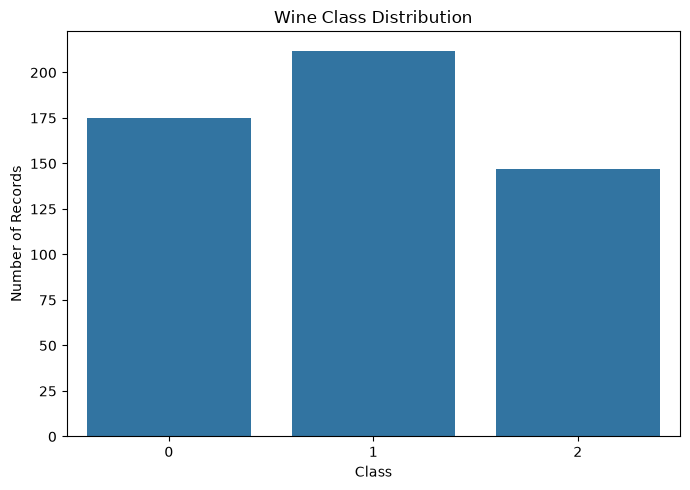

,count
target,
0,175
1,212
2,147


In [8]:
class_counts = df[target_column].value_counts().sort_index()

plt.figure(figsize=(7, 5))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values)
plt.title("Wine Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "class_distribution.png", dpi=150)
plt.show()

display(class_counts.to_frame("count"))

## 5. Prepare features and target

In [9]:
X, y = prepare_features(df, target_column)

print("Feature columns:")
print(X.columns.tolist())
print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature columns:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Feature matrix shape: (534, 13)
Target shape: (534,)


## 6. Feature distributions

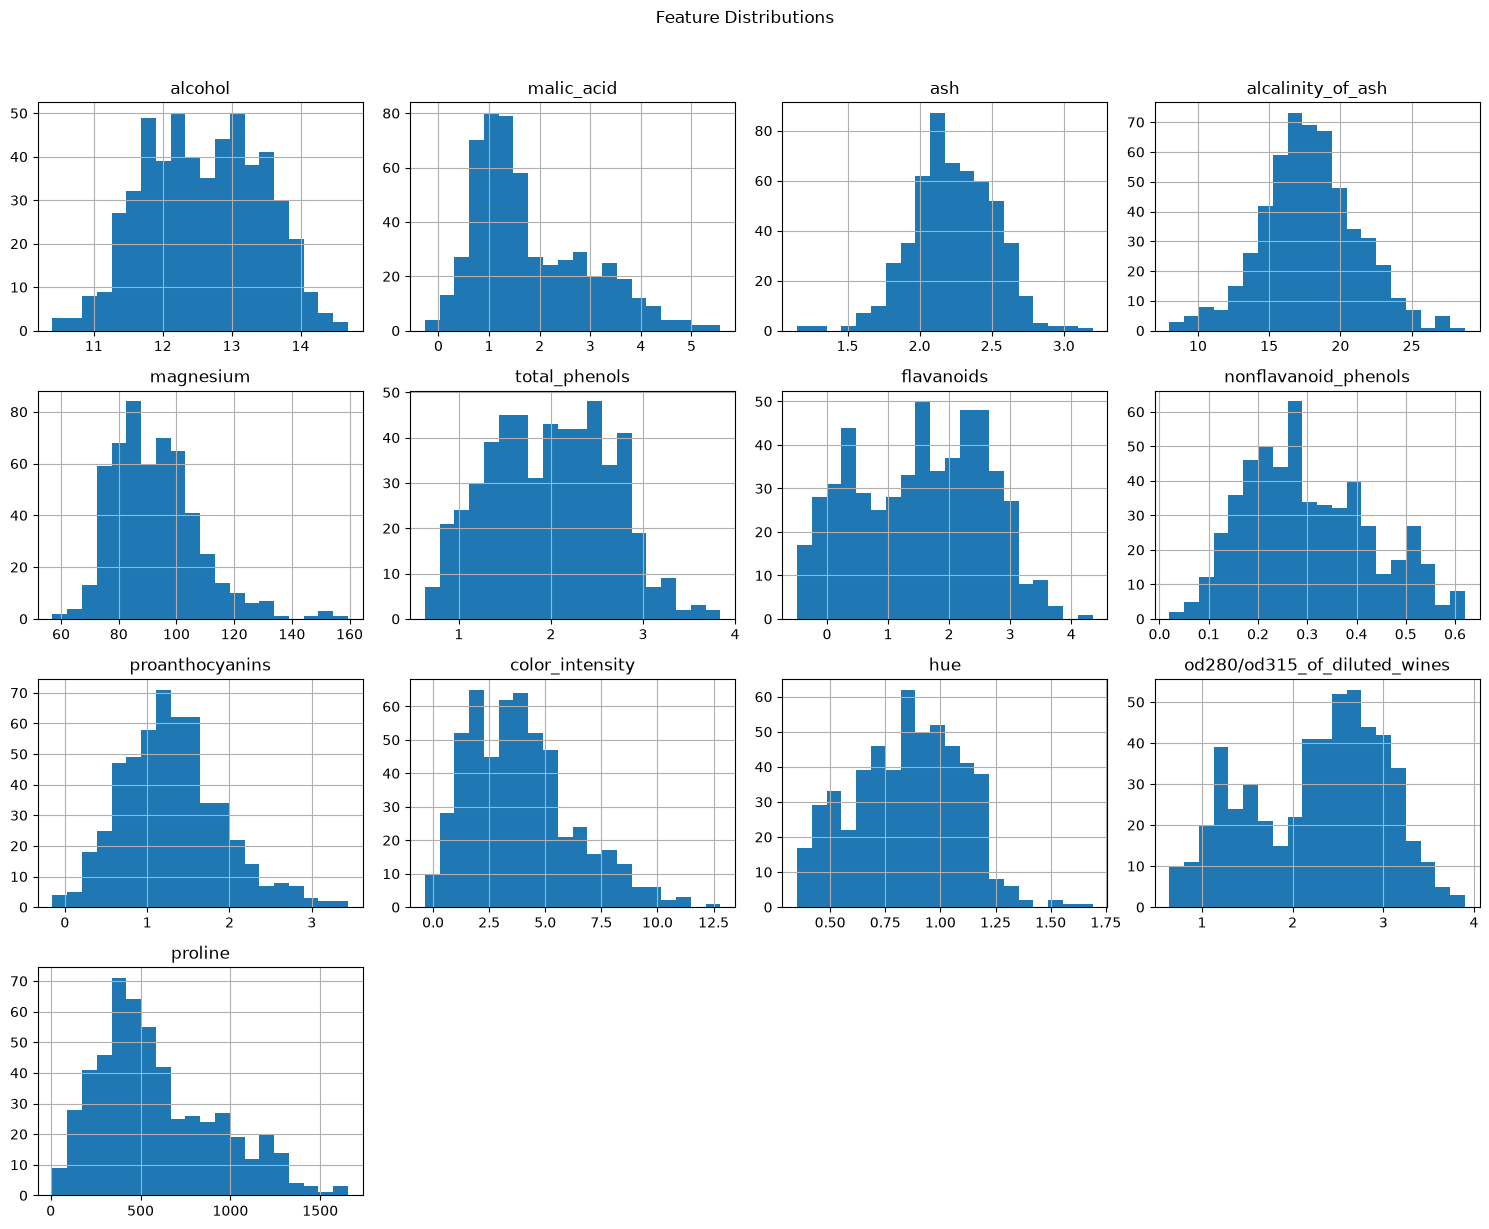

In [10]:
X.hist(figsize=(15, 12), bins=20)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "feature_distributions.png", dpi=150)
plt.show()

## 7. Feature correlation

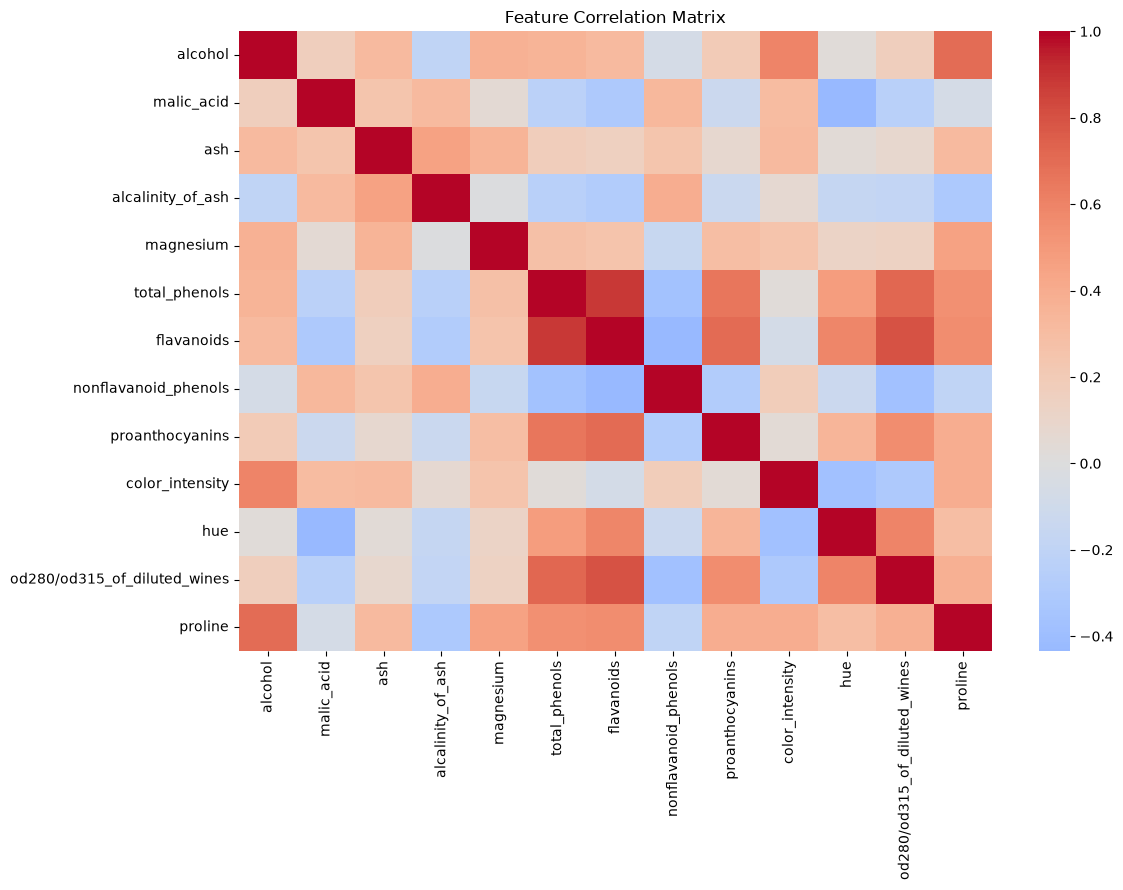

In [11]:
plt.figure(figsize=(12, 9))
sns.heatmap(X.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "correlation_heatmap.png", dpi=150)
plt.show()

## 8. Train/test split

In [12]:
X_train, X_test, y_train, y_test = make_train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("\nTraining class distribution:")
display(y_train.value_counts(normalize=True).sort_index())
print("\nTesting class distribution:")
display(y_test.value_counts(normalize=True).sort_index())

Training rows: 427
Testing rows: 107

Training class distribution:


target
0    0.327869
1    0.395785
2    0.276347
Name: proportion, dtype: float64


Testing class distribution:


target
0    0.327103
1    0.401869
2    0.271028
Name: proportion, dtype: float64

## 9. Train Gaussian Naive Bayes

Gaussian Naive Bayes assumes each numeric feature follows a Gaussian distribution within each class.

A `StandardScaler` is included in the pipeline so that the workflow is consistent and reproducible. For GaussianNB itself, scaling does not fundamentally change the class likelihood calculation in the same way it can for distance-based models, but the pipeline makes preprocessing explicit and reusable.

In [13]:
model = make_scaling_pipeline(GaussianNB())
model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)

print("Model trained successfully.")
print("Classes:", model.classes_)

Model trained successfully.
Classes: [0 1 2]


## 10. Evaluate the model

In [14]:
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification report:")
print(classification_report(y_test, predictions, zero_division=0))

Accuracy: 0.9346

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96        35
           1       0.95      0.88      0.92        43
           2       0.88      1.00      0.94        29

    accuracy                           0.93       107
   macro avg       0.93      0.94      0.94       107
weighted avg       0.94      0.93      0.93       107



## 11. Confusion matrix

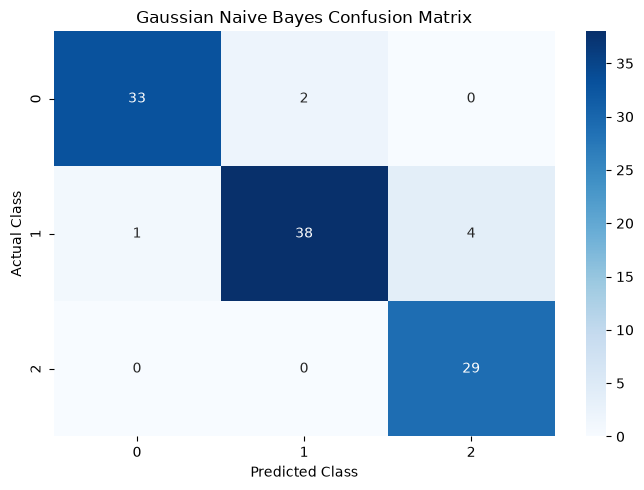

Confusion matrix:
[[33  2  0]
 [ 1 38  4]
 [ 0  0 29]]


In [15]:
cm = confusion_matrix(y_test, predictions, labels=model.classes_)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_,
)
plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "confusion_matrix.png", dpi=150)
plt.show()

print("Confusion matrix:")
print(cm)

## 12. Error analysis

In [16]:
error_df = X_test.copy()
error_df["actual"] = y_test
error_df["predicted"] = predictions
error_df["correct"] = error_df["actual"] == error_df["predicted"]

errors = error_df[~error_df["correct"]].copy()

print("Incorrect predictions:", len(errors))
print("Error rate:", f"{len(errors) / len(error_df):.2%}")

display(errors.head(10))

Incorrect predictions: 7
Error rate: 6.54%


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,actual,predicted,correct
133,12.13,0.65,1.85,14.69,90.97,1.62,0.78,0.45,0.26,4.28,0.840,1.14,250.88,1,2,False
455,12.24,0.82,1.89,15.17,93.04,1.72,0.92,0.47,0.34,4.62,0.870,1.24,296.56,1,2,False
515,13.09,0.98,1.69,14.91,77.63,2.96,3.15,0.26,2.27,5.24,1.110,3.16,493.86,1,0,False
218,12.10,0.62,1.84,14.60,90.59,1.61,0.75,0.45,0.24,4.22,0.830,1.12,242.45,1,2,False
148,11.89,1.07,2.08,18.77,96.05,0.80,0.53,0.31,1.18,1.92,0.796,1.47,716.67,1,2,False
172,12.59,1.42,3.07,23.12,115.96,2.28,2.12,0.40,1.60,2.27,1.000,2.80,652.64,0,1,False
294,12.25,2.86,2.42,15.80,90.01,1.88,1.57,0.15,1.50,2.55,0.840,2.92,505.54,0,1,False


### Most common misclassification pairs

In [17]:
misclassification_pairs = (
    errors.groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(misclassification_pairs)

,actual,predicted,count
2,1,2,4
0,0,1,2
1,1,0,1


## 13. Cross-validation

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy",
)

print("Cross-validation accuracy scores:")
print(np.round(cv_scores, 4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"CV standard deviation: {cv_scores.std():.4f}")

Cross-validation accuracy scores:
[0.9346 0.9346 0.972  0.9626 0.9434]
Mean CV accuracy: 0.9494
CV standard deviation: 0.0152


## 14. Save the trained model

In [19]:
import joblib

model_path = MODEL_DIR / "gaussian_naive_bayes.joblib"

joblib.dump(
    {
        "model": model,
        "feature_names": X.columns.tolist(),
        "target_column": target_column,
    },
    model_path,
)

print("Saved model to:", model_path)

Saved model to: c:\Bea\Documents\Project\Wine Quality Naive Bayes\wine-quality-naive-bayes\models\gaussian_naive_bayes.joblib


## 15. Prediction using test data set

In [24]:

import pandas as pd
import joblib

MODEL_DIR = PROJECT_ROOT / "models"
TEST_PATH = PROJECT_ROOT / "data" / "test.csv"

artifact = joblib.load(MODEL_DIR / "gaussian_naive_bayes.joblib")

model = artifact["model"]
features = artifact["feature_names"]

test = pd.read_csv(TEST_PATH)

ids = test["id"]
X_test = test[features]

predictions = model.predict(X_test)

submission = pd.DataFrame({
    "id": ids,
    "prediction": predictions
})

submission.to_csv("test_predictions.csv", index=False)
